# Multilingual Embedding Exploration

This notebook explores whether multilingual transformer embeddings preserve semantic similarity across English, German, and Russian.

Research Question:
Can multilingual embeddings place semantically equivalent sentences close together regardless of language?

Experiments:
- Encode equivalent sentences across languages
- Compute cosine similarity
- Inspect cross-lingual semantic alignment

### Import Dependencies

In [2]:
# Libraries required for embedding generation and similarity analysis
import sys
from pathlib import Path

parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

c:\Users\Nikolai\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Multilingual Embedding Model

In [3]:
# Load the multilingual transformer encoder.
# This model maps multiple languages into a shared semantic vector space.

MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

encoder = SentenceTransformer(MODEL_NAME)

print("Loaded embedding model:")
print(MODEL_NAME)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7479.69it/s]


Loaded embedding model:
sentence-transformers/paraphrase-multilingual-mpnet-base-v2


### Create Multilingual Semantic Examples

In [4]:
# Create semantically equivalent sentences across English,
# German, and Russian.

examples = [
    {
        "concept": "environmental_policy",
        "language": "English",
        "text": "The government announced a new environmental policy."
    },
    {
        "concept": "environmental_policy",
        "language": "German",
        "text": "Die Regierung kündigte eine neue Umweltpolitik an."
    },
    {
        "concept": "environmental_policy",
        "language": "Russian",
        "text": "Правительство объявило новую экологическую политику."
    },
    {
        "concept": "animal_sleeping",
        "language": "English",
        "text": "The dog is sleeping."
    },
    {
        "concept": "animal_sleeping",
        "language": "German",
        "text": "Der Hund schläft."
    },
    {
        "concept": "animal_sleeping",
        "language": "Russian",
        "text": "Собака спит."
    },
    {
    "concept": "renewable_energy",
    "language": "English",
    "text": "The country invested in renewable energy infrastructure."
    },
    {
        "concept": "renewable_energy",
        "language": "German",
        "text": "Das Land investierte in Infrastruktur für erneuerbare Energien."
    },
    {
        "concept": "renewable_energy",
        "language": "Russian",
        "text": "Страна инвестировала в инфраструктуру возобновляемой энергетики."
    }
]


documents = pd.DataFrame(examples)

documents

,concept,language,text
0,environmental_policy,English,The government announced a new environmental p...
1,environmental_policy,German,Die Regierung kündigte eine neue Umweltpolitik...
2,environmental_policy,Russian,Правительство объявило новую экологическую пол...
3,animal_sleeping,English,The dog is sleeping.
4,animal_sleeping,German,Der Hund schläft.
5,animal_sleeping,Russian,Собака спит.
6,renewable_energy,English,The country invested in renewable energy infra...
7,renewable_energy,German,Das Land investierte in Infrastruktur für erne...
8,renewable_energy,Russian,Страна инвестировала в инфраструктуру возобнов...


### Generate Embeddings

In [5]:
# Convert each sentence into a dense semantic vector.

embeddings = encoder.encode(
    documents["text"].tolist(),
    normalize_embeddings=True
)

print("Embedding matrix shape:")
print(embeddings.shape)

Embedding matrix shape:
(9, 768)


### Calculate Semantic Similarity

In [6]:
# Compare every sentence against every other sentence.
# Higher cosine similarity means closer semantic representation.

similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=documents["language"] + ": " + documents["text"],
    columns=documents["language"] + ": " + documents["text"]
)

similarity_df.round(3)

,English: The government announced a new environmental policy.,German: Die Regierung kündigte eine neue Umweltpolitik an.,Russian: Правительство объявило новую экологическую политику.,English: The dog is sleeping.,German: Der Hund schläft.,Russian: Собака спит.,English: The country invested in renewable energy infrastructure.,German: Das Land investierte in Infrastruktur für erneuerbare Energien.,Russian: Страна инвестировала в инфраструктуру возобновляемой энергетики.
English: The government announced a new environmental policy.,1.000,0.987,0.986,-0.019,-0.019,-0.025,0.403,0.426,0.415
German: Die Regierung kündigte eine neue Umweltpolitik an.,0.987,1.000,0.986,-0.045,-0.044,-0.051,0.419,0.445,0.433
Russian: Правительство объявило новую экологическую политику.,0.986,0.986,1.000,-0.051,-0.048,-0.054,0.424,0.445,0.437
English: The dog is sleeping.,-0.019,-0.045,-0.051,1.000,0.991,0.991,0.006,0.000,-0.008
German: Der Hund schläft.,-0.019,-0.044,-0.048,0.991,1.000,0.995,0.003,-0.002,-0.011
Russian: Собака спит.,-0.025,-0.051,-0.054,0.991,0.995,1.000,-0.000,-0.006,-0.015
English: The country invested in renewable energy infrastructure.,0.403,0.419,0.424,0.006,0.003,-0.000,1.000,0.976,0.988
German: Das Land investierte in Infrastruktur für erneuerbare Energien.,0.426,0.445,0.445,0.000,-0.002,-0.006,0.976,1.000,0.981
Russian: Страна инвестировала в инфраструктуру возобновляемой энергетики.,0.415,0.433,0.437,-0.008,-0.011,-0.015,0.988,0.981,1.000


### Extract Cross-Lingual Comparisons

In [7]:
# Compare only sentences representing the same concept
# but written in different languages.

results = [] # Initialize empty list to store results of similarity comparisons

# Iterate through each pair of sentences in the documents DataFrame
for i, row_i in documents.iterrows():
    # Compare each sentence with every other sentence
    for j, row_j in documents.iterrows():
        # Check if two sentences represent same concept but in different languages
        if (
            row_i["concept"] == row_j["concept"]
            and row_i["language"] != row_j["language"]
        ):
            # Store concept, language pair, and similarity score in esults list
            results.append(
                {
                    "Concept": row_i["concept"],
                    "Language Pair": (
                        f"{row_i['language']} → {row_j['language']}"
                    ),
                    "Similarity": similarity_matrix[i][j]
                }
            )

# Create DataFrame from results list to analyze cross-language similarity scores
cross_language_similarity = pd.DataFrame(results)
# Sort DataFrame by similarity score in descending order to see most similar first
cross_language_similarity.sort_values(
    by = "Similarity",
    ascending = False
)

,Concept,Language Pair,Similarity
11,animal_sleeping,Russian → German,0.994564
9,animal_sleeping,German → Russian,0.994564
10,animal_sleeping,Russian → English,0.990752
7,animal_sleeping,English → Russian,0.990752
8,animal_sleeping,German → English,0.990543
6,animal_sleeping,English → German,0.990543
16,renewable_energy,Russian → English,0.988469
13,renewable_energy,English → Russian,0.988469
2,environmental_policy,German → English,0.986685
0,environmental_policy,English → German,0.986685


### Visualize Similarity Distribution

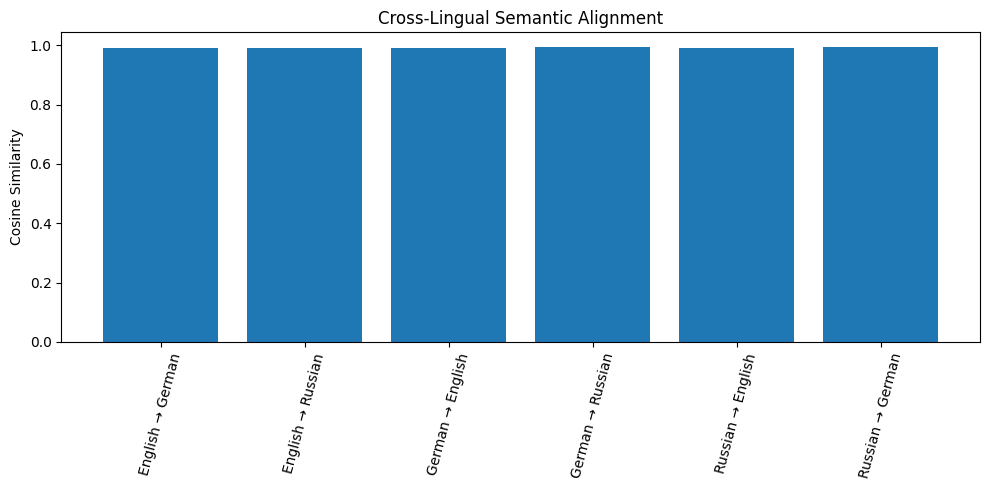

In [8]:
# Visualize whether multilingual representations cluster
# semantically equivalent sentences together.

plt.figure(figsize=(10,5))

plt.bar(
    cross_language_similarity["Language Pair"],
    cross_language_similarity["Similarity"]
)

plt.xticks(rotation=75)
plt.ylabel("Cosine Similarity")
plt.title(
    "Cross-Lingual Semantic Alignment"
)

plt.tight_layout()
plt.show()

### Linguistic Analysis

The experiment intentionally uses languages with different structural properties.

English:
- analytic language
- meaning often distributed across separate words

German:
- compound-heavy morphology
- lexical compression

Russian:
- inflection-rich morphology
- grammatical meaning encoded in word endings

The goal is not perfect translation equivalence, but whether embeddings preserve semantic relationships despite structural differences.

### Interpretation

Expected behavior:

- Equivalent meanings across languages should produce high similarity scores.
- Language identity should matter less than semantic content.
- Morphological differences should not completely prevent alignment.

Observations from this experiment:

1. Multilingual encoders create shared semantic spaces.
2. Translation is not required for retrieval.
3. Remaining differences reveal linguistic challenges:
   - morphology
   - word order
   - compound formation
   - lexical ambiguity

This establishes the embedding foundation for later experiments:

- semantic search
- retrieval evaluation
- morphology-aware preprocessing
- linguistic error analysis